In [916]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import contextily as cx
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import dill
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from scipy.stats import f_oneway
from scipy.stats import shapiro
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



Importing the Dataset "airbnb.csv".

In [917]:
df_original = pd.read_csv('airbnb.csv', low_memory=False)

Viewing the Data.

In [918]:
df_original.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75356,-73.98559,Entire home/apt,150,30,49,2022-06-21,0.30,3,314,1,NaN
1,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68535,-73.95512,Private room,60,30,50,2019-12-02,0.30,2,365,0,NaN
2,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80380,-73.96751,Private room,75,2,118,2017-07-21,0.72,1,0,0,NaN
3,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Midtown,40.76457,-73.98317,Private room,68,2,575,2023-02-19,3.41,1,106,52,NaN
4,5136,"Large Sunny Brooklyn Duplex, Patio + Garden",7378,Rebecca,Brooklyn,Sunset Park,40.66265,-73.99454,Entire home/apt,275,60,3,2022-08-10,0.03,1,181,1,NaN


Dropping 'id' and 'host_id' because they do not contribute to our model. Also, dropping 'license' because it is a null column and irrelevant.

In [919]:
df=df_original.drop(columns=["id","host_id","license"])

Viewing the shape (Rows, Columns) of the Dataset.

In [920]:
df.shape

(42931, 15)

Inspect Column Names.

In [921]:
df.columns

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'number_of_reviews_ltm'],
      dtype='object')

Basic Info.

In [922]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42931 entries, 0 to 42930
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            42919 non-null  object 
 1   host_name                       42926 non-null  object 
 2   neighbourhood_group             42931 non-null  object 
 3   neighbourhood                   42931 non-null  object 
 4   latitude                        42931 non-null  float64
 5   longitude                       42931 non-null  float64
 6   room_type                       42931 non-null  object 
 7   price                           42931 non-null  int64  
 8   minimum_nights                  42931 non-null  int64  
 9   number_of_reviews               42931 non-null  int64  
 10  last_review                     32627 non-null  object 
 11  reviews_per_month               32627 non-null  float64
 12  calculated_host_listings_count  

Handling Null Values

In [923]:
# Create a DataFrame for null value counts
null_counts = df.isnull().sum().reset_index()
null_counts.columns = ['Feature', 'Null Value Count']

# Filter to show only features with at least one null
null_counts = null_counts[null_counts['Null Value Count'] > 0]

# Display the result# Show all features including those with 0 nulls
null_counts = df.isnull().sum().reset_index()
null_counts.columns = ['Feature', 'Null Value Count']

# Display full table
null_counts

null_counts


,Feature,Null Value Count
0,name,12
1,host_name,5
2,neighbourhood_group,0
3,neighbourhood,0
4,latitude,0
5,longitude,0
6,room_type,0
7,price,0
8,minimum_nights,0
9,number_of_reviews,0


We have 12 and 5 null values in 'name' column and 'host_name' column respectively. Replacing all of those with "unknown".

In [924]:
#'host_name' fill missing values
df['name'] = df['name'].fillna('unknown')
df['host_name'] = df['host_name'].fillna('unknown')

We have 10304 missing values in both 'last_review' as well as 'reviews_per_month'. Replacing the null last_review values by 0 and reviews_per_month by the median value using the SimpleImputer.

In [925]:
null_rows_idx = df.isnull().any(axis=1)
df["last_review"] = df["last_review"].fillna(0)
df.loc[null_rows_idx].head()

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
15,Room in the heart of Astoria,Boris,Queens,Astoria,40.76336,-73.92099,Private room,55,30,0,0,NaN,1,0,0
47,Country space in the city,Harriet,Brooklyn,Flatbush,40.63702,-73.96327,Private room,150,30,0,0,NaN,1,0,0
88,Room in Beautiful Townhouse.,L,Bronx,Mott Haven,40.80635,-73.92201,Private room,60,30,0,0,NaN,1,83,0
101,1 Bedroom in 2 Bdrm Apt- Upper East,Jessica,Manhattan,Upper East Side,40.77449,-73.95308,Private room,130,14,0,0,NaN,2,0,0
114,Beautiful Uptown Manhattan apartmnt,Douglas,Manhattan,Harlem,40.80255,-73.95803,Private room,200,30,0,0,NaN,1,365,0


In [926]:
imputer = SimpleImputer(strategy='median')
df['reviews_per_month'] = imputer.fit_transform(df[['reviews_per_month']])
df[['reviews_per_month']].median()


reviews_per_month    0.52
dtype: float64

All the null values have been handled.

In [927]:
df.isnull().sum()

name                              0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
dtype: int64

Looking in to the consistency of the data types of all our features.

In [928]:
print(df.dtypes)

name                               object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
dtype: object


Converting 'last_review' column from object to datetime.

In [929]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
df.head(5)

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,40.75356,-73.98559,Entire home/apt,150,30,49,2022-06-21,0.30,3,314,1
1,BlissArtsSpace!,Garon,Brooklyn,Bedford-Stuyvesant,40.68535,-73.95512,Private room,60,30,50,2019-12-02,0.30,2,365,0
2,Cozy Clean Guest Room - Family Apt,MaryEllen,Manhattan,Upper West Side,40.80380,-73.96751,Private room,75,2,118,2017-07-21,0.72,1,0,0
3,Large Furnished Room Near B'way,Shunichi,Manhattan,Midtown,40.76457,-73.98317,Private room,68,2,575,2023-02-19,3.41,1,106,52
4,"Large Sunny Brooklyn Duplex, Patio + Garden",Rebecca,Brooklyn,Sunset Park,40.66265,-73.99454,Entire home/apt,275,60,3,2022-08-10,0.03,1,181,1


In [930]:
print(df.dtypes)

name                                      object
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm                      int64
dtype: object


Removing any duplicate observations if there are any.

In [931]:
df.drop_duplicates(inplace=True)

There are no duplicate rows. Hence, the shape of our dataframe remains the same as the original.

In [932]:
df.shape

(42921, 15)

Inspecting Variables.

In [933]:
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,42921.000000,42921.000000,42921.000000,42921.000000,42921.000000,32626,42921.000000,42921.000000,42921.000000,42921.000000
mean,40.728267,-73.943658,200.189651,18.115165,25.862002,2021-08-16 22:13:45.795377920,1.013349,24.057082,140.255865,7.738310
min,40.500314,-74.251907,0.000000,1.000000,0.000000,2011-05-12 00:00:00,0.010000,1.000000,0.000000,0.000000
25%,40.687480,-73.981750,75.000000,2.000000,1.000000,2020-03-10 00:00:00,0.220000,1.000000,0.000000,0.000000
50%,40.724020,-73.952600,125.000000,7.000000,5.000000,2022-11-23 00:00:00,0.520000,1.000000,89.000000,1.000000
75%,40.762298,-73.924020,200.000000,30.000000,24.000000,2023-02-01 00:00:00,1.170000,4.000000,289.000000,7.000000
max,40.911380,-73.710870,99000.000000,1250.000000,1842.000000,2023-03-06 00:00:00,86.610000,526.000000,365.000000,1093.000000
std,0.057646,0.056631,895.147544,27.464470,56.621574,NaN,1.584775,80.877199,141.994403,18.292005


Correlation Heatmap for the numeric features.

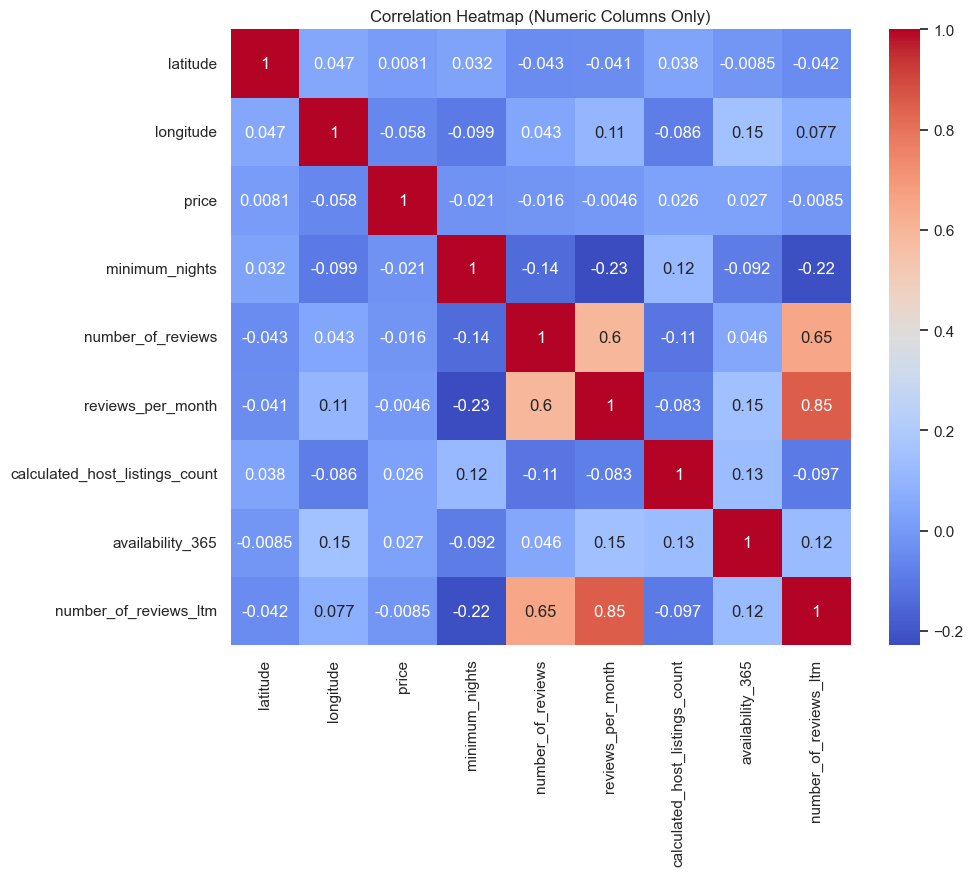

In [934]:
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_data = df[numeric_cols]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Columns Only)")
plt.show()

In [935]:
print((df['price'] > 1000).sum())
print((df['price'] <= 1000).sum())


625
42296


In [936]:
df = df[df['price'] <= 1000]


---
# Part 1: Price Prediction (Regression)

Before classifying listings into price ranges, we first attempt to **predict the exact nightly price** as a continuous value using regression models.

We compare three models:
- **Linear Regression** — interpretable baseline with mathematical insight
- **Random Forest Regressor** — ensemble method capturing nonlinear relationships
- **XGBoost Regressor** — gradient boosting for maximum predictive power

Each model is evaluated with RMSE, MAE, and R², and supported with visual diagnostics.


## 1.1 Prepare Regression Features

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Use the cleaned df before price_range is added ──
# Select numeric + encoded categorical features, target = price
reg_df = df.copy()

# Drop non-predictive text/date columns
drop_cols = ['name', 'host_name', 'last_review', 'price_range'] 
drop_cols = [c for c in drop_cols if c in reg_df.columns]
reg_df = reg_df.drop(columns=drop_cols)

# One-hot encode categoricals if not already done
cat_cols = reg_df.select_dtypes(include='object').columns.tolist()
if cat_cols:
    reg_df = pd.get_dummies(reg_df, columns=cat_cols, drop_first=True)

# Features and target
X_reg = reg_df.drop(columns=['price'])
y_reg = reg_df['price']

# Train / test split (80/20)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# Scale features
scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

print(f"Train size: {X_reg_train.shape}  |  Test size: {X_reg_test.shape}")
print(f"Target range: ${y_reg.min():.0f} – ${y_reg.max():.0f}  |  Mean: ${y_reg.mean():.2f}")

## 1.2 Price Distribution

Understanding the target variable before modelling.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(y_reg, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Price (USD)'); axes[0].set_ylabel('Count')

# Log-transformed distribution
axes[1].hist(np.log1p(y_reg), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Price Distribution (Log-Transformed)', fontsize=13)
axes[1].set_xlabel('log(Price + 1)'); axes[1].set_ylabel('Count')

plt.suptitle('Target Variable: Nightly Price', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness (raw)     : {y_reg.skew():.3f}")
print(f"Skewness (log+1)   : {np.log1p(y_reg).skew():.3f}")
print("Log transformation significantly reduces right skew — beneficial for linear models.")

## 1.3 Regression Helper: Evaluation & Plots

A shared function to evaluate any regression model consistently.


In [ ]:
def evaluate_regression(model_name, y_true, y_pred):
    """Print RMSE, MAE, R² and return as dict."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  RMSE : ${rmse:.2f}")
    print(f"  MAE  : ${mae:.2f}")
    print(f"  R²   : {r2:.4f}")
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

def plot_predictions(y_true, y_pred, model_name, color='steelblue'):
    """Actual vs Predicted scatter + Residuals plot."""
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Actual vs Predicted
    axes[0].scatter(y_true, y_pred, alpha=0.3, color=color, edgecolors='none', s=15)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Price ($)'); axes[0].set_ylabel('Predicted Price ($)')
    axes[0].set_title(f'{model_name}\nActual vs Predicted')
    axes[0].legend()

    # Residuals vs Predicted
    axes[1].scatter(y_pred, residuals, alpha=0.3, color=color, edgecolors='none', s=15)
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1].set_xlabel('Predicted Price ($)'); axes[1].set_ylabel('Residual ($)')
    axes[1].set_title(f'{model_name}\nResiduals vs Predicted')

    # Residual distribution
    axes[2].hist(residuals, bins=50, color=color, edgecolor='white', alpha=0.85)
    axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[2].set_xlabel('Residual ($)'); axes[2].set_ylabel('Count')
    axes[2].set_title(f'{model_name}\nResidual Distribution')

    plt.suptitle(f'Regression Diagnostics — {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

reg_results = []  # Collect all model metrics here
print("Helper functions defined.")

---
## 1.4 Linear Regression

### Mathematical Foundation

Linear Regression models the relationship between features **X** and target **y** as:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

The coefficients **β** are estimated by minimising the **Residual Sum of Squares (RSS)**:

$$\text{RSS} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

The closed-form solution (Normal Equation) is:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

**Evaluation Metrics:**
- **RMSE** = $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ — penalises large errors
- **MAE** = $\frac{1}{n}\sum|y_i - \hat{y}_i|$ — robust to outliers
- **R²** = $1 - \frac{\text{RSS}}{\text{TSS}}$ — proportion of variance explained (1 = perfect)


In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_reg_train_sc, y_reg_train)
lr_pred  = lr_model.predict(X_reg_test_sc)

# Evaluate
lr_metrics = evaluate_regression("Linear Regression", y_reg_test, lr_pred)
reg_results.append(lr_metrics)

In [ ]:
# Coefficient analysis — which features drive price the most?
coef_df = pd.DataFrame({
    'Feature'    : X_reg_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression — Top 15 Feature Coefficients\n(Blue = price ↑, Red = price ↓)', fontsize=13)
plt.tight_layout()
plt.show()

print("Positive coefficients → feature increases predicted price")
print("Negative coefficients → feature decreases predicted price")

In [ ]:
# Diagnostic plots
plot_predictions(y_reg_test, lr_pred, "Linear Regression", color='steelblue')

---
## 1.5 Random Forest Regressor

Random Forest builds many decorrelated decision trees and averages their predictions:

$$\hat{y}_{RF} = \frac{1}{B} \sum_{b=1}^{B} T_b(\mathbf{x})$$

where $T_b$ is the $b$-th tree trained on a bootstrap sample with random feature subsets.

**Key advantages over Linear Regression:**
- Captures non-linear relationships automatically
- Robust to outliers and irrelevant features
- Provides feature importances


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_reg_param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_reg_gs = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_reg_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1, verbose=1
)

rf_reg_gs.fit(X_reg_train, y_reg_train)
rf_reg_pred = rf_reg_gs.best_estimator_.predict(X_reg_test)

print("Best params:", rf_reg_gs.best_params_)
rf_metrics = evaluate_regression("Random Forest Regressor (Tuned)", y_reg_test, rf_reg_pred)
reg_results.append(rf_metrics)

In [ ]:
# Feature importance
rf_imp_df = pd.DataFrame({
    'Feature'   : X_reg_train.columns,
    'Importance': rf_reg_gs.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(rf_imp_df['Feature'][::-1], rf_imp_df['Importance'][::-1], color='forestgreen')
plt.xlabel('Feature Importance Score')
plt.title('Random Forest Regressor — Top 15 Feature Importances', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Diagnostic plots
plot_predictions(y_reg_test, rf_reg_pred, "Random Forest Regressor", color='forestgreen')

---
## 1.6 XGBoost Regressor

XGBoost uses **gradient boosting** — it builds trees sequentially where each tree corrects the residual errors of the previous:

$$\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta \cdot f_t(\mathbf{x})$$

where $f_t$ is the $t$-th tree, $\eta$ is the learning rate, and the objective at step $t$ minimises:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$

The regularisation term $\Omega(f_t) = \gamma T + \frac{1}{2}\lambda \|w\|^2$ controls tree complexity.

**Key advantages:**
- Handles missing values natively
- Built-in L1/L2 regularisation prevents overfitting
- Typically the best performer on tabular data


In [ ]:
from xgboost import XGBRegressor

xgb_reg_param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [4, 6, 8],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0]
}

xgb_reg_gs = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_reg_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1, verbose=1
)

xgb_reg_gs.fit(X_reg_train, y_reg_train)
xgb_reg_pred = xgb_reg_gs.best_estimator_.predict(X_reg_test)

print("Best params:", xgb_reg_gs.best_params_)
xgb_metrics = evaluate_regression("XGBoost Regressor (Tuned)", y_reg_test, xgb_reg_pred)
reg_results.append(xgb_metrics)

In [ ]:
# XGBoost feature importance
xgb_imp_df = pd.DataFrame({
    'Feature'   : X_reg_train.columns,
    'Importance': xgb_reg_gs.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(xgb_imp_df['Feature'][::-1], xgb_imp_df['Importance'][::-1], color='darkorange')
plt.xlabel('Feature Importance Score')
plt.title('XGBoost Regressor — Top 15 Feature Importances', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Diagnostic plots
plot_predictions(y_reg_test, xgb_reg_pred, "XGBoost Regressor", color='darkorange')

---
## 1.7 Regression Model Comparison


In [ ]:
reg_comparison = pd.DataFrame(reg_results).set_index('Model').round(4)
print(reg_comparison.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics   = ['RMSE', 'MAE', 'R2']
colors    = ['tomato', 'steelblue', 'forestgreen']
titles    = ['RMSE (lower is better)', 'MAE (lower is better)', 'R² (higher is better)']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    ax.bar(reg_comparison.index, reg_comparison[metric], color=color, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticklabels(reg_comparison.index, rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Regression Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Combined ROC-style: Actual vs Predicted overlay for all 3 models
plt.figure(figsize=(10, 6))
sample_idx = np.random.choice(len(y_reg_test), size=300, replace=False)
y_sample   = y_reg_test.values[sample_idx]

plt.scatter(y_sample, lr_pred[sample_idx],      alpha=0.5, label='Linear Regression', color='steelblue',   s=20)
plt.scatter(y_sample, rf_reg_pred[sample_idx],  alpha=0.5, label='Random Forest',     color='forestgreen', s=20)
plt.scatter(y_sample, xgb_reg_pred[sample_idx], alpha=0.5, label='XGBoost',           color='darkorange',  s=20)
lims = [y_sample.min(), y_sample.max()]
plt.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual Price ($)'); plt.ylabel('Predicted Price ($)')
plt.title('All Regression Models — Actual vs Predicted (300 sample)', fontsize=13)
plt.legend(); plt.tight_layout(); plt.show()

---
# Part 2: Price Range Classification (≤$500 Affordable vs >$500 Expensive)

Having explored exact price prediction above, we now frame this as a **binary classification problem**.  
Each listing is labelled:
- **Affordable** → price ≤ $500  
- **Expensive**  → price > $500

The classification pipeline uses SMOTE to handle class imbalance, PCA for dimensionality reduction, and compares Logistic Regression, Decision Tree, and Random Forest classifiers.

---


Creating a new column "price_range" where price<500 is Affordable and price>500 is Expensive

In [937]:
def classify_price(price):
    if price <= 500:
        return 'Affordable'
    else:
        return 'Expensive'

df['price_range'] = df['price'].apply(classify_price)
df.head()


,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,price_range
0,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,40.75356,-73.98559,Entire home/apt,150,30,49,2022-06-21,0.30,3,314,1,Affordable
1,BlissArtsSpace!,Garon,Brooklyn,Bedford-Stuyvesant,40.68535,-73.95512,Private room,60,30,50,2019-12-02,0.30,2,365,0,Affordable
2,Cozy Clean Guest Room - Family Apt,MaryEllen,Manhattan,Upper West Side,40.80380,-73.96751,Private room,75,2,118,2017-07-21,0.72,1,0,0,Affordable
3,Large Furnished Room Near B'way,Shunichi,Manhattan,Midtown,40.76457,-73.98317,Private room,68,2,575,2023-02-19,3.41,1,106,52,Affordable
4,"Large Sunny Brooklyn Duplex, Patio + Garden",Rebecca,Brooklyn,Sunset Park,40.66265,-73.99454,Entire home/apt,275,60,3,2022-08-10,0.03,1,181,1,Affordable


Shapiro Wilk Normality Test

In [938]:
X = df.drop(columns=['price', 'price_range'])
y = df['price_range']

# Step 3: Filter only numeric predictors
X_numeric = X.select_dtypes(include=['int64', 'float64'])

# Step 4: Apply Shapiro-Wilk normality test to each numeric predictor
print("🔍 Shapiro-Wilk Normality Test Results:\n")
for col in X_numeric.columns:
    stat, p = shapiro(X_numeric[col].dropna())
    result = '✅ Normal' if p > 0.05 else '❌ Not Normal'
    print(f"{col:30s} p-value = {p:.4f} {result}")

🔍 Shapiro-Wilk Normality Test Results:

latitude                       p-value = 0.0000 ❌ Not Normal
longitude                      p-value = 0.0000 ❌ Not Normal
minimum_nights                 p-value = 0.0000 ❌ Not Normal
number_of_reviews              p-value = 0.0000 ❌ Not Normal
reviews_per_month              p-value = 0.0000 ❌ Not Normal
calculated_host_listings_count p-value = 0.0000 ❌ Not Normal
availability_365               p-value = 0.0000 ❌ Not Normal
number_of_reviews_ltm          p-value = 0.0000 ❌ Not Normal


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 42296.
  res = hypotest_fun_out(*samples, **kwds)


Kruskal Wallis Test

In [939]:
from scipy.stats import kruskal

# Define target and predictors
target_col = 'price_range'
X = df.drop(columns=['price', 'price_range'])  # predictors only
y = df['price_range']

# Filter numeric columns only
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Prepare results
results = []
for col in numeric_cols:
    # Group by target and extract values per group
    groups = [group[col].dropna().values for name, group in df.groupby(target_col)]
    
    # Perform Kruskal-Wallis test
    stat, p = kruskal(*groups)
    
    # Save result
    results.append({
        'Feature': col,
        'KW_Stat': round(stat, 2),
        'KW_P': round(p, 4),
        'KW_Significant': p < 0.05
    })

# Convert to DataFrame
kw_results_df = pd.DataFrame(results)
kw_results_df = kw_results_df[['Feature', 'KW_Stat', 'KW_P', 'KW_Significant']].sort_values(by='KW_Stat', ascending=False)

# Display the result
from IPython.display import display
display(kw_results_df.style.set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#ccc')]}]
).set_properties(**{'text-align': 'center'}))


,Feature,KW_Stat,KW_P,KW_Significant
1,longitude,684.800000,0.000000,True
3,number_of_reviews,218.190000,0.000000,True
2,minimum_nights,184.490000,0.000000,True
6,availability_365,167.460000,0.000000,True
5,calculated_host_listings_count,52.180000,0.000000,True
0,latitude,51.910000,0.000000,True
7,number_of_reviews_ltm,45.020000,0.000000,True
4,reviews_per_month,0.260000,0.611000,False


One Hot Encoding the Categorical Columns "neighbourhood_group" and "room_type"

In [940]:
from sklearn.preprocessing import OneHotEncoder

# Selecting the categorical columns
cat_columns = ['neighbourhood_group', 'room_type']
cat_data = df[cat_columns]

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cat = encoder.fit_transform(cat_data)

encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(cat_columns),
    index=df.index
)

# Dropping original categorical columns
df = df.drop(columns=cat_columns)

# Concatenating encoded columns to main DataFrame
df = pd.concat([df, encoded_cat_df], axis=1)

df.head()

,name,host_name,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,...,availability_365,number_of_reviews_ltm,price_range,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,Skylit Midtown Castle,Jennifer,Midtown,40.75356,-73.98559,150,30,49,2022-06-21,0.30,...,314,1,Affordable,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,BlissArtsSpace!,Garon,Bedford-Stuyvesant,40.68535,-73.95512,60,30,50,2019-12-02,0.30,...,365,0,Affordable,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Cozy Clean Guest Room - Family Apt,MaryEllen,Upper West Side,40.80380,-73.96751,75,2,118,2017-07-21,0.72,...,0,0,Affordable,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,Large Furnished Room Near B'way,Shunichi,Midtown,40.76457,-73.98317,68,2,575,2023-02-19,3.41,...,106,52,Affordable,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,"Large Sunny Brooklyn Duplex, Patio + Garden",Rebecca,Sunset Park,40.66265,-73.99454,275,60,3,2022-08-10,0.03,...,181,1,Affordable,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Because of Class Imbalance on our target variable, using SMOTE to multiply the minority class.

In [941]:
df['price_range'].value_counts()

price_range
Affordable    40961
Expensive      1335
Name: count, dtype: int64

In [942]:
from sklearn.model_selection import train_test_split

X = df.select_dtypes(include=['int64', 'float64']).drop(columns=['price'])  # drop target price
y = df['price_range']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [943]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Use only the minority classes
smote = SMOTE(sampling_strategy={
    'Expensive': 10000
}, random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE: ", Counter(y_resampled))


Before SMOTE: Counter({'Affordable': 32768, 'Expensive': 1068})
After SMOTE:  Counter({'Affordable': 32768, 'Expensive': 10000})


Principal Component Analysis (PCA)

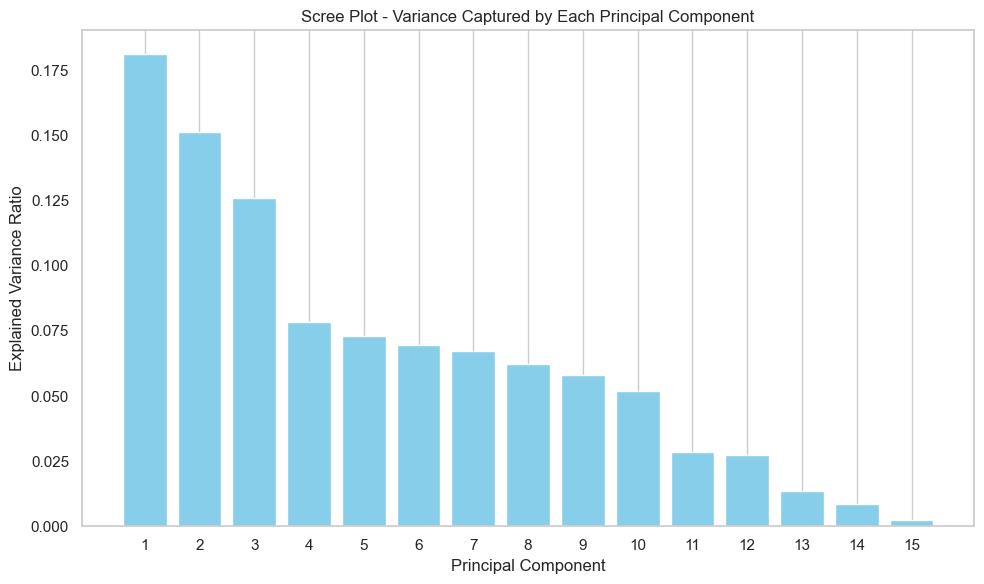

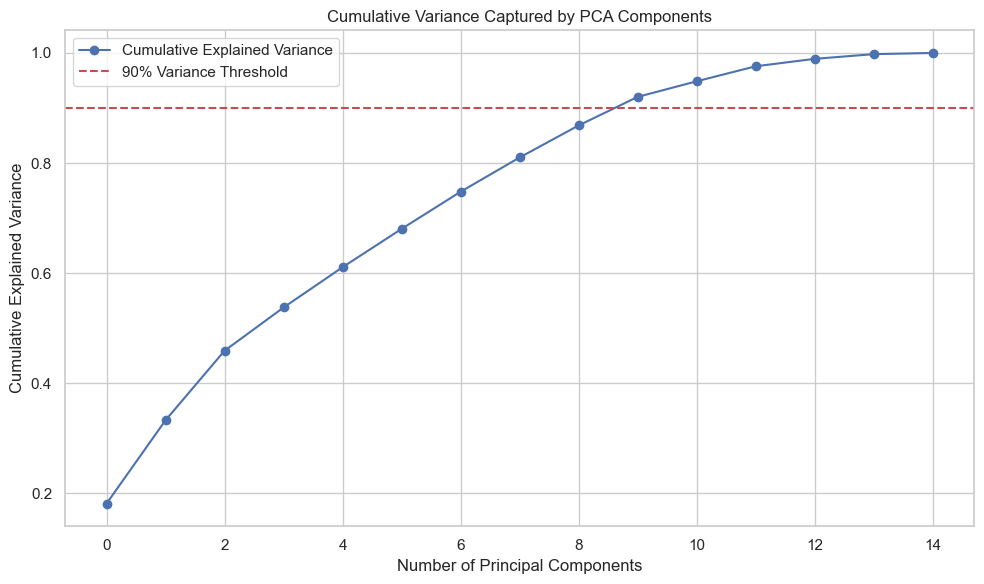

PCA completed. Final shape: (42768, 11)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,price_range
0,0.469703,-2.124865,-0.981863,-0.923877,-0.445506,0.214144,0.516835,-0.350091,0.909386,-0.417086,Affordable
1,0.744792,2.227376,-1.160505,-0.688554,0.138523,0.186819,-0.459232,0.873227,-0.573116,-0.020088,Affordable
2,-1.911508,1.306583,1.498065,-0.869495,-1.524761,-0.726038,-0.520422,0.203324,1.212946,-0.688567,Affordable
3,6.442780,2.111835,1.842752,-0.216207,0.137657,0.205157,-0.580227,0.992019,-1.133501,-1.267475,Affordable
4,0.132316,-1.856970,-0.662659,-1.311254,-0.516200,0.126416,0.207052,0.333107,0.825128,0.077935,Affordable


In [944]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#Scale the SMOTEd feature set
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled) 

#PCA
pca_full = PCA()
pca_full.fit(X_scaled)

# Step 3: Plot Scree Plot (individual explained variance per PC)
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_,
        color='skyblue')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - Variance Captured by Each Principal Component')
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', label='Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance Captured by PCA Components')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Apply PCA with 90% variance
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)

#Add target column back
X_pca_df['price_range'] = y_resampled.reset_index(drop=True)

print(f"PCA completed. Final shape: {X_pca_df.shape}")
X_pca_df.head()


Train-Test Split

In [945]:
from sklearn.model_selection import train_test_split

X = X_pca_df.drop(columns=['price_range'])
y = X_pca_df['price_range']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


Logistic Regression Model

Accuracy: 0.7934299742810381
Classification Report:
               precision    recall  f1-score   support

  Affordable       0.82      0.94      0.87      6554
   Expensive       0.62      0.30      0.41      2000

    accuracy                           0.79      8554
   macro avg       0.72      0.62      0.64      8554
weighted avg       0.77      0.79      0.77      8554



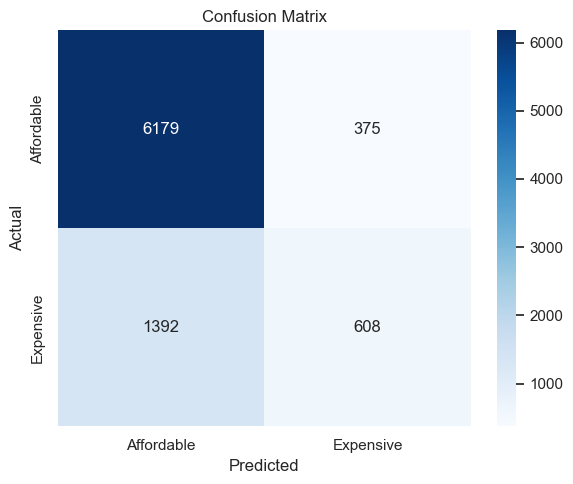

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

# Predict
logreg_pred = logreg_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, logreg_pred))
print("Classification Report:\n", classification_report(y_test, logreg_pred))

# Confusion Matrix
logreg_cm = confusion_matrix(y_test, logreg_pred, labels=logreg_model.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(logreg_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=logreg_model.classes_, yticklabels=logreg_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

ROC AUC Curve for Logistic Regression

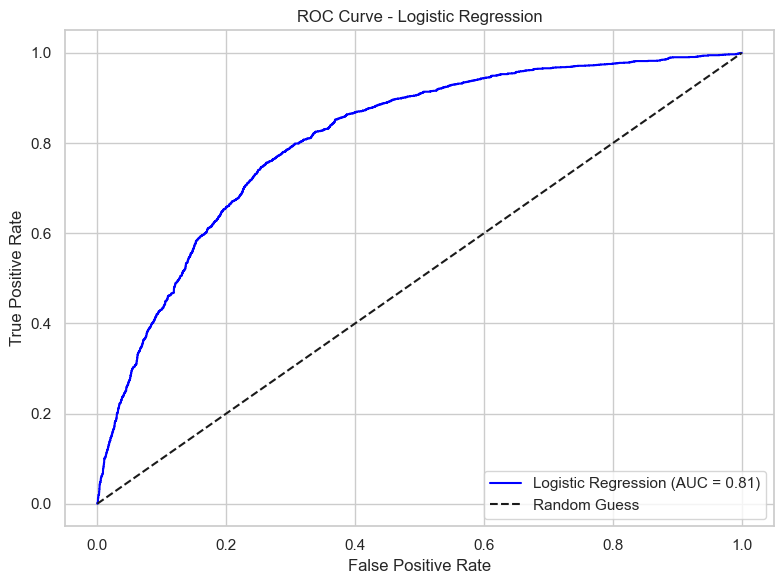

In [947]:
from sklearn.metrics import roc_curve, auc

logreg_y_score = logreg_model.predict_proba(X_test)[:, 1]  # Probability of class 'Expensive'

# Compute ROC curve and AUC
logreg_fpr, logreg_tpr, logreg_thresholds = roc_curve(y_test, logreg_y_score, pos_label='Expensive')
logreg_auc = auc(logreg_fpr, logreg_tpr)

plt.figure(figsize=(8, 6))
plt.plot(logreg_fpr, logreg_tpr, label=f'Logistic Regression (AUC = {logreg_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Grid Search on Logistic Regression

In [948]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#Hyperparameter grid
logreg_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga']
}

logreg_base_model = LogisticRegression(max_iter=1000)

# Grid Search with 5-fold cross-validation
logreg_grid_search = GridSearchCV(
    estimator=logreg_base_model,
    param_grid=logreg_param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

logreg_grid_search.fit(X_train, y_train)

logreg_best_model = logreg_grid_search.best_estimator_

logreg_y_pred_best = logreg_best_model.predict(X_test)

# Results
print("Best Parameters:", logreg_grid_search.best_params_)
print("Best CV Accuracy:", logreg_grid_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, logreg_y_pred_best))
print("Classification Report:\n", classification_report(y_test, logreg_y_pred_best))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Best CV Accuracy: 0.7922487846275997
Test Accuracy: 0.7933130699088146
Classification Report:
               precision    recall  f1-score   support

  Affordable       0.82      0.94      0.87      6554
   Expensive       0.62      0.30      0.41      2000

    accuracy                           0.79      8554
   macro avg       0.72      0.62      0.64      8554
weighted avg       0.77      0.79      0.77      8554



Decision Tree

Accuracy: 0.8995791442599953
Classification Report (Decision Tree)               precision    recall  f1-score   support

  Affordable       0.94      0.93      0.93      6554
   Expensive       0.78      0.79      0.79      2000

    accuracy                           0.90      8554
   macro avg       0.86      0.86      0.86      8554
weighted avg       0.90      0.90      0.90      8554



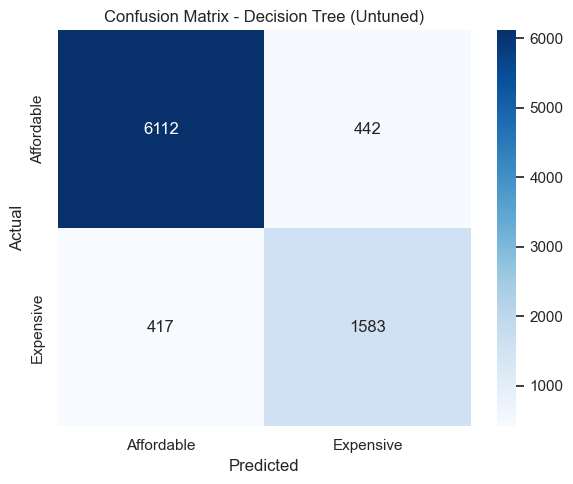

In [949]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X_train, y_train)

# Predict
dtree_y_pred = dtree_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, dtree_y_pred))
print("Classification Report (Decision Tree)", classification_report(y_test, dtree_y_pred))

# Confusion matrix
dtree_cm = confusion_matrix(y_test, dtree_y_pred, labels=dtree_model.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(dtree_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dtree_model.classes_,
            yticklabels=dtree_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Untuned)")
plt.tight_layout()
plt.show()


Grid Search on Decision Tree

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy (DT GridSearch): 0.8995791442599953
Classification Report (DT GridSearch):
               precision    recall  f1-score   support

  Affordable       0.94      0.93      0.93      6554
   Expensive       0.78      0.79      0.79      2000

    accuracy                           0.90      8554
   macro avg       0.86      0.86      0.86      8554
weighted avg       0.90      0.90      0.90      8554



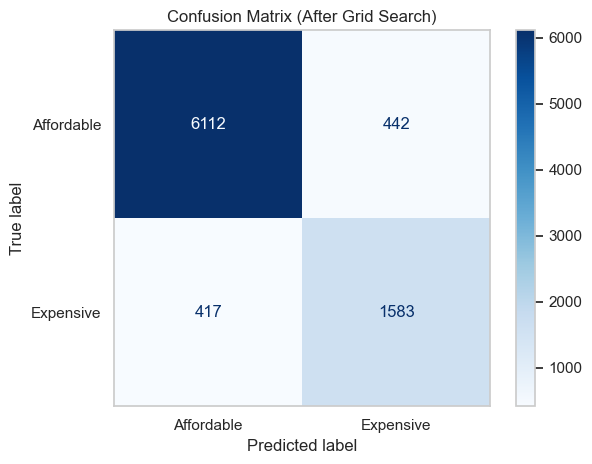

In [950]:
# Define parameter grid for Decision Tree
dtree_gs_param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dtree_gs_model = DecisionTreeClassifier(random_state=42)

dtree_gs_search = GridSearchCV(
    estimator=dtree_gs_model,
    param_grid=dtree_gs_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

dtree_gs_search.fit(X_train, y_train)

dtree_gs_y_pred = dtree_gs_search.best_estimator_.predict(X_test)

# Evaluate
print("Best Parameters:", dtree_gs_search.best_params_)
print("Accuracy (DT GridSearch):", accuracy_score(y_test, dtree_gs_y_pred))
print("Classification Report (DT GridSearch):\n", classification_report(y_test, dtree_gs_y_pred))

# Confusion Matrix
dtree_gs_cm = confusion_matrix(y_test, dtree_gs_y_pred, labels=dtree_gs_search.best_estimator_.classes_)
dtree_gs_disp = ConfusionMatrixDisplay(confusion_matrix=dtree_gs_cm,
                                       display_labels=dtree_gs_search.best_estimator_.classes_)
dtree_gs_disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix (After Grid Search)")
plt.grid(False)
plt.tight_layout()
plt.show()


Feature Importance on Decsion Tree

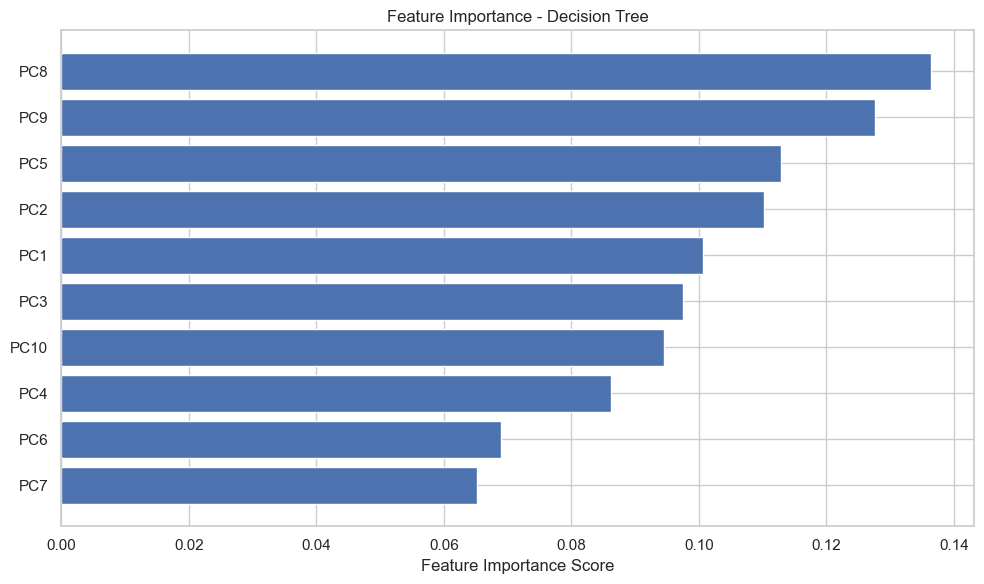

In [951]:
importances = dtree_gs_search.best_estimator_.feature_importances_

# Get corresponding feature names
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
plt.xlabel("Feature Importance Score")
plt.title("Feature Importance - Decision Tree")
plt.tight_layout()
plt.show()


ROC AUC Curve for Decision Tree

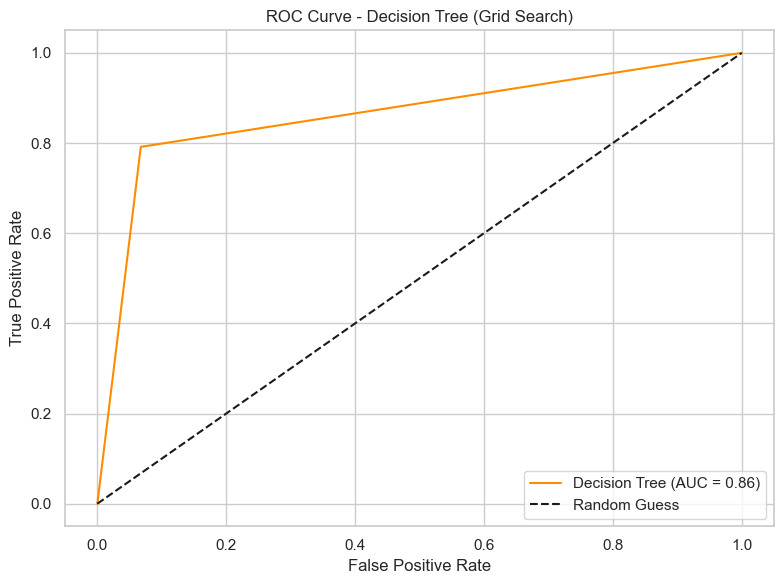

In [ ]:
dtree_gs_y_score = dtree_gs_search.best_estimator_.predict_proba(X_test)[:, 1]

dtree_gs_fpr, dtree_gs_tpr, _ = roc_curve(y_test, dtree_gs_y_score, pos_label='Expensive')
dtree_gs_auc = auc(dtree_gs_fpr, dtree_gs_tpr)

plt.figure(figsize=(8, 6))
plt.plot(dtree_gs_fpr, dtree_gs_tpr, label=f'Decision Tree (AUC = {dtree_gs_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree (Grid Search)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Decision Tree Visualization

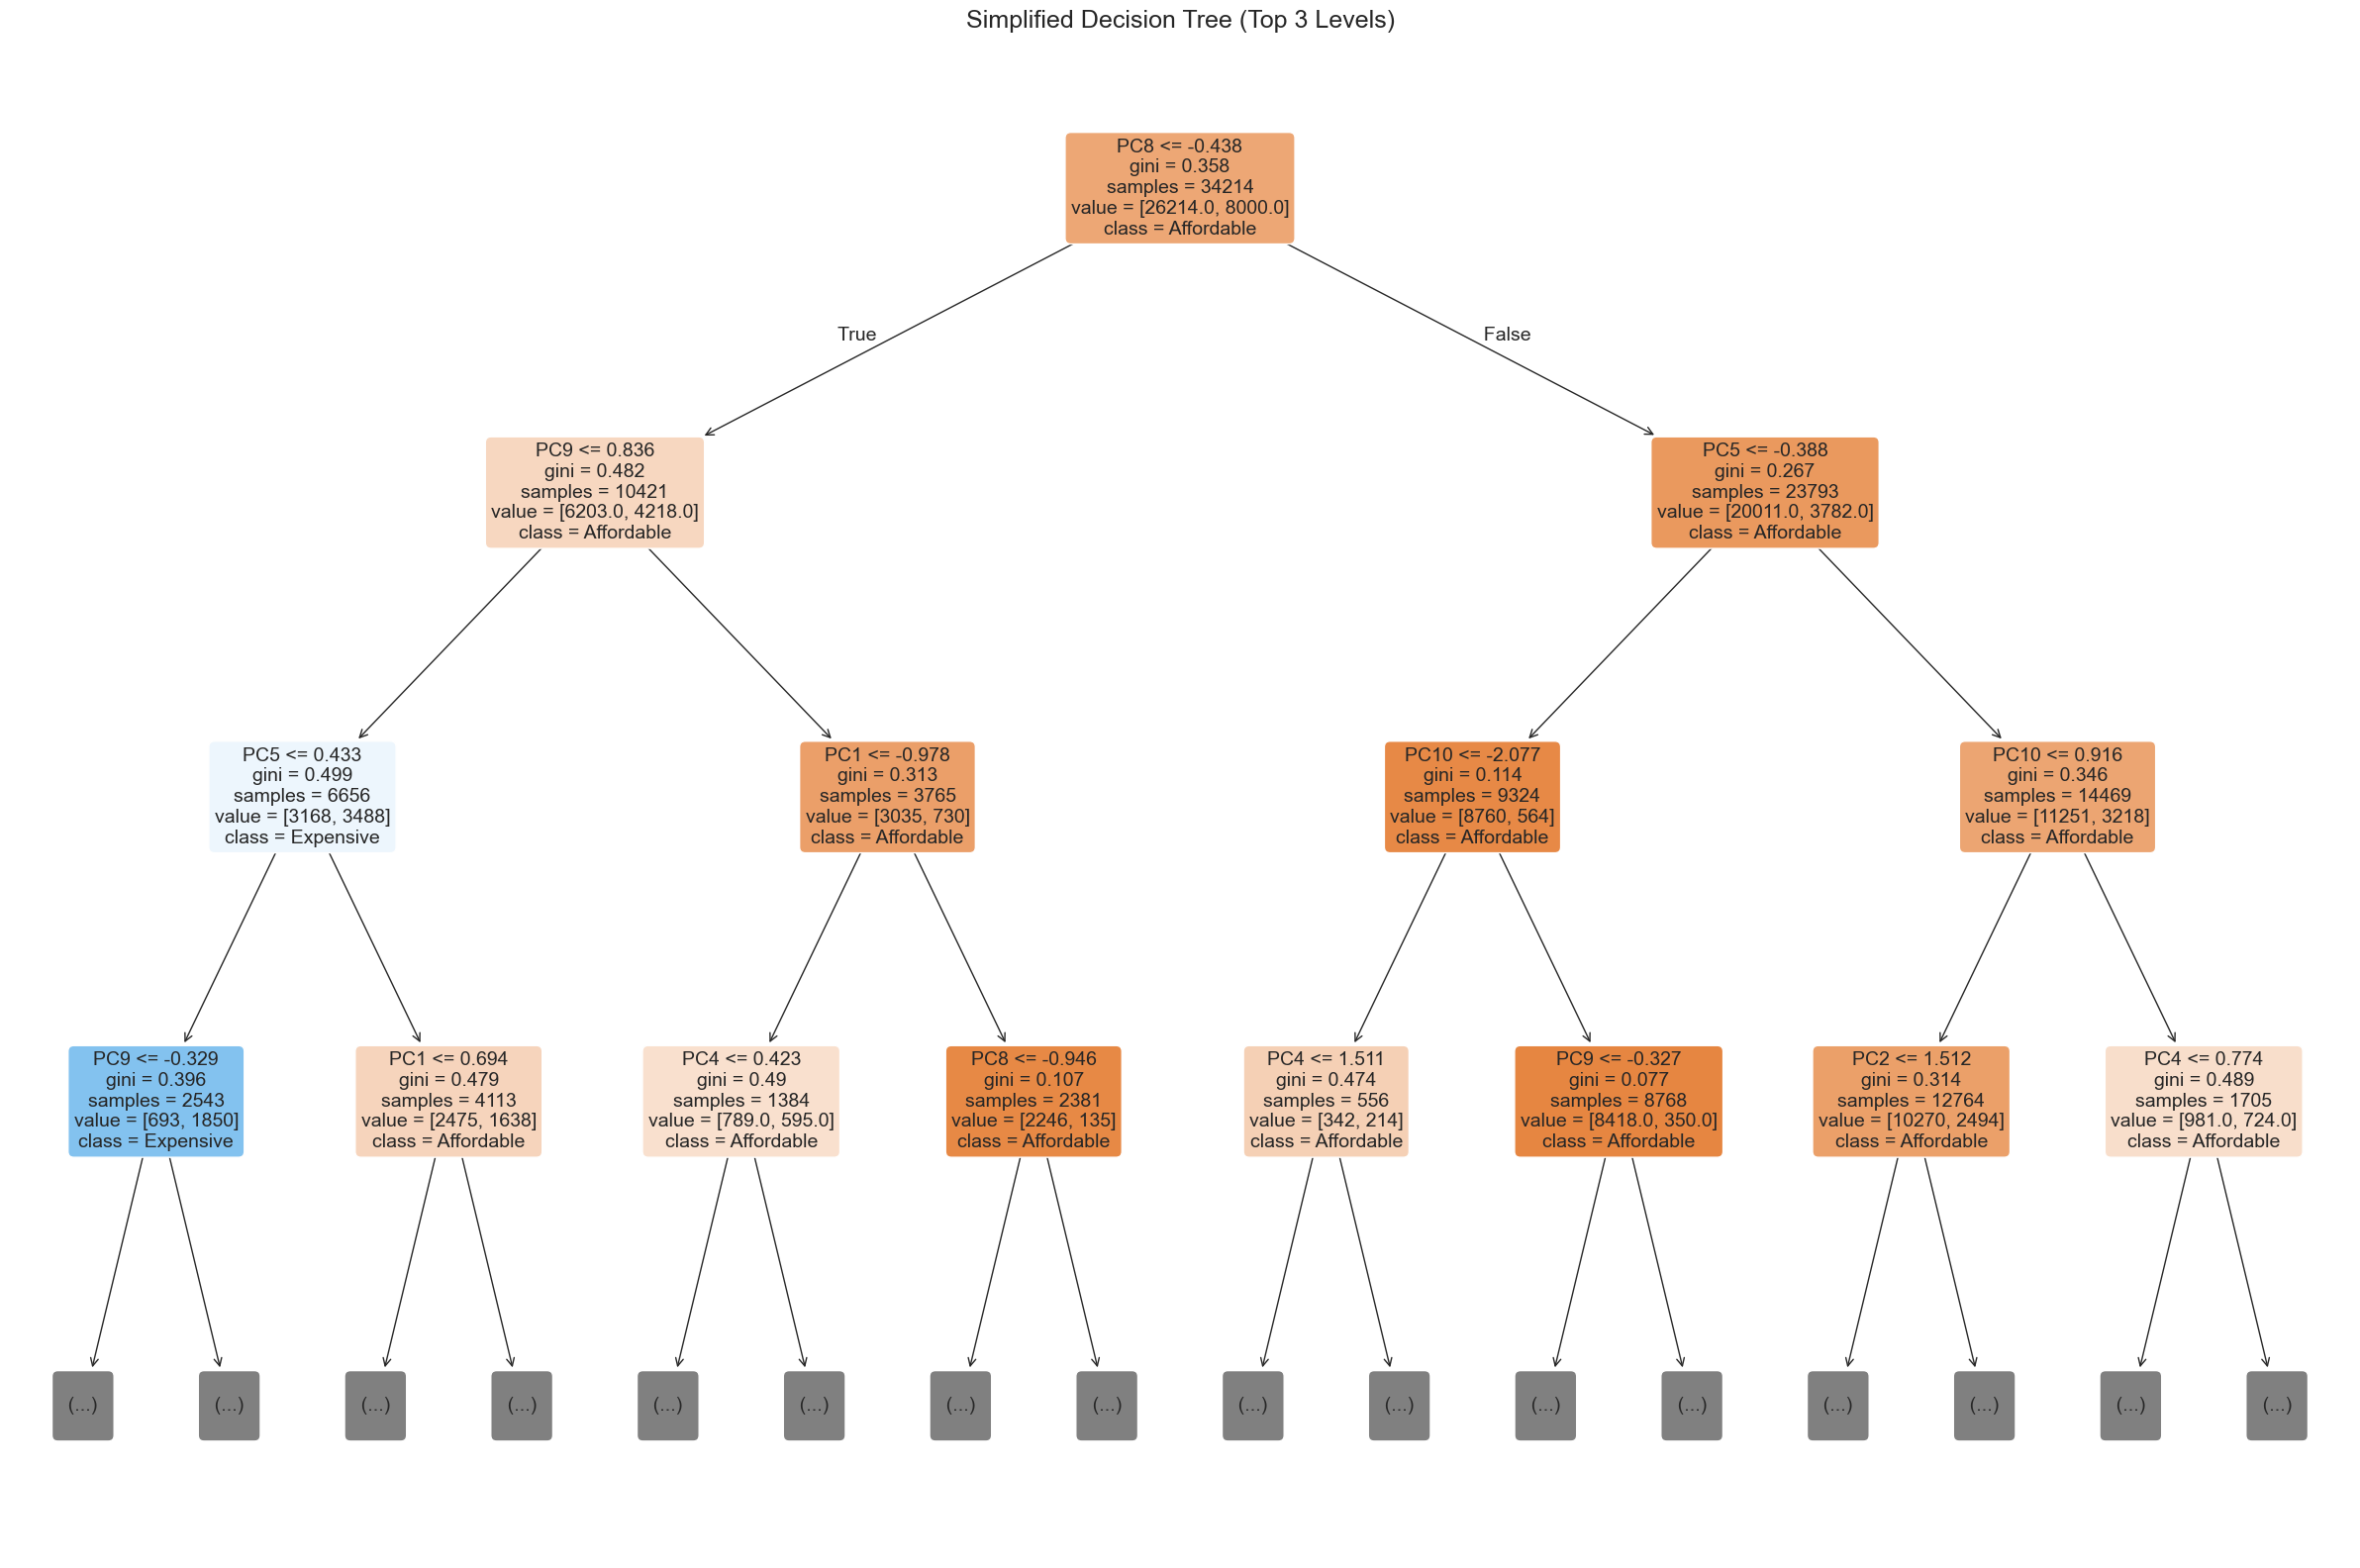

In [909]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 16))  # Bigger canvas for better readability

plot_tree(
    dtree_gs_search.best_estimator_,
    max_depth=3,  # Limit depth for simplicity
    filled=True,
    feature_names=X_train.columns,
    class_names=dtree_gs_search.best_estimator_.classes_,
    rounded=True,
    fontsize=14  # Increase font size for clarity
)

plt.title("Simplified Decision Tree (Top 3 Levels)", fontsize=18)
plt.tight_layout()
plt.show()


Random Forest

✅ Accuracy (Random Forest): 0.936520925882628

📋 Classification Report (Random Forest):
               precision    recall  f1-score   support

  Affordable       0.95      0.97      0.96      6554
   Expensive       0.89      0.83      0.86      2000

    accuracy                           0.94      8554
   macro avg       0.92      0.90      0.91      8554
weighted avg       0.94      0.94      0.94      8554



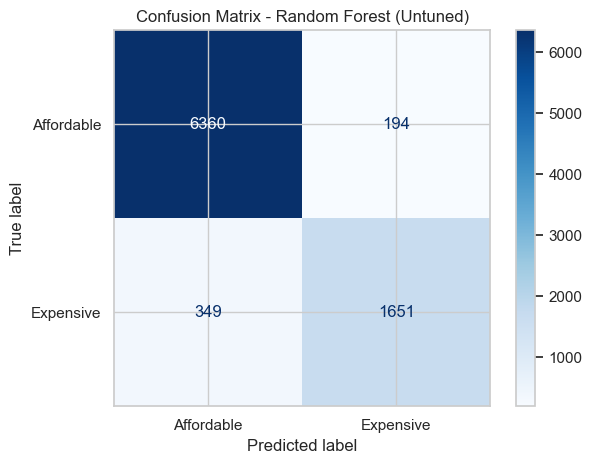

In [910]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_y_pred = rf_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, rf_y_pred))
print("Classification Report (Random Forest):\n", classification_report(y_test, rf_y_pred))

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_y_pred, labels=rf_model.classes_)
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=rf_model.classes_)
rf_disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Random Forest (Untuned)")
plt.tight_layout()
plt.show()


Grid Search on Random Forest

Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
✅ Accuracy (Tuned RF): 0.936754734627075

📋 Classification Report (Tuned RF):
               precision    recall  f1-score   support

  Affordable       0.95      0.97      0.96      6554
   Expensive       0.89      0.83      0.86      2000

    accuracy                           0.94      8554
   macro avg       0.92      0.90      0.91      8554
weighted avg       0.94      0.94      0.94      8554



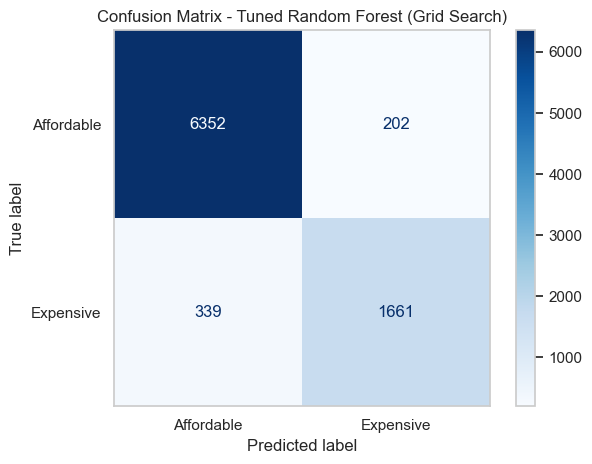

In [911]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Hyperparameter grid
rf_gs_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

#GridSearch
rf_gs_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_gs_param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_gs_search.fit(X_train, y_train)

# Predict
rf_gs_y_pred = rf_gs_search.best_estimator_.predict(X_test)

# Evaluate
print("Best Parameters:", rf_gs_search.best_params_)
print("Accuracy:", accuracy_score(y_test, rf_gs_y_pred))
print("Classification Report:\n", classification_report(y_test, rf_gs_y_pred))

# Confusion Matrix
rf_gs_cm = confusion_matrix(y_test, rf_gs_y_pred, labels=rf_gs_search.best_estimator_.classes_)
rf_gs_disp = ConfusionMatrixDisplay(confusion_matrix=rf_gs_cm, display_labels=rf_gs_search.best_estimator_.classes_)
rf_gs_disp.plot(cmap='Blues', values_format='d')
plt.grid(False)
plt.title("Confusion Matrix - Tuned Random Forest (Grid Search)")
plt.tight_layout()
plt.show()


Feature Importance of Random Forest

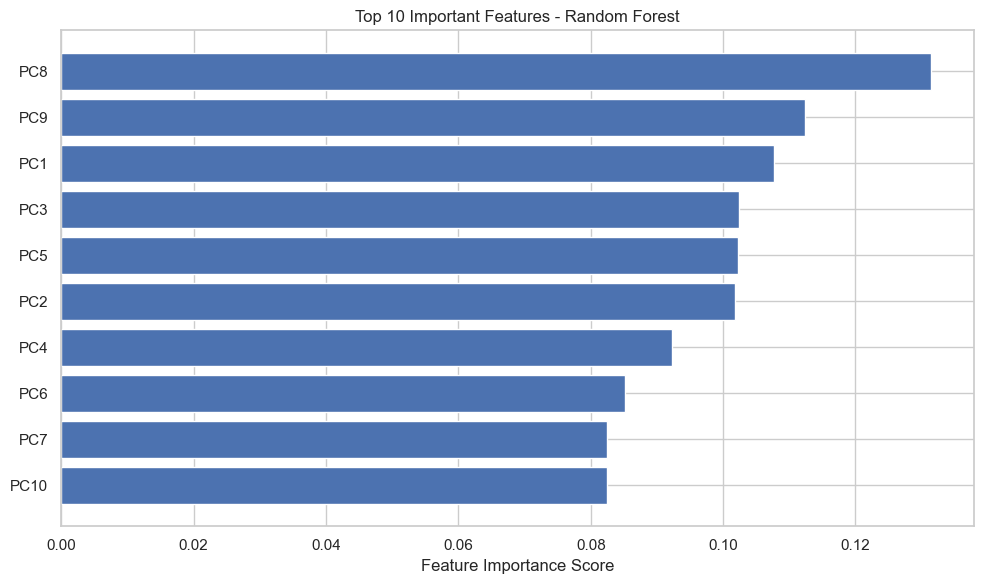

In [ ]:
rf_importances = rf_gs_search.best_estimator_.feature_importances_

rf_feature_names = X_train.columns

rf_importance_df = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_importances
})

rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df['Feature'][:10][::-1], rf_importance_df['Importance'][:10][::-1])
plt.xlabel("Feature Importance Score")
plt.title("Features - Random Forest")
plt.tight_layout()
plt.show()

ROC AUC Curve for Random Forest after Grid Search

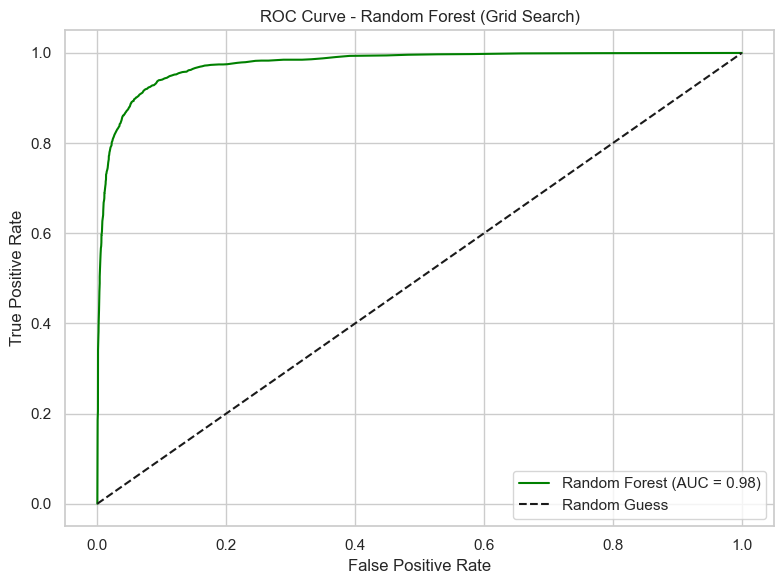

In [ ]:
rf_gs_y_score = rf_gs_search.best_estimator_.predict_proba(X_test)[:, 1]

rf_gs_fpr, rf_gs_tpr, _ = roc_curve(y_test, rf_gs_y_score, pos_label='Expensive')
rf_gs_auc = auc(rf_gs_fpr, rf_gs_tpr)

plt.figure(figsize=(8, 6))
plt.plot(rf_gs_fpr, rf_gs_tpr, label=f'Random Forest (AUC = {rf_gs_auc:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Grid Search)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [956]:

pc8_vector = pca.components_[7]  # 8th principal component (index 7)

if len(pc8_vector) != X_scaled_df.shape[1]:
    print(f"Mismatch: PC8 length = {len(pc8_vector)}, X_scaled_df has {X_scaled_df.shape[1]} columns")
    # Fix by slicing only matching columns
    matching_columns = X_scaled_df.columns[:len(pc8_vector)]
else:
    matching_columns = X_scaled_df.columns

pc8_df = pd.DataFrame({
    'Original Feature': matching_columns,
    'PC8 Coefficient': pc8_vector
})

pc8_df['AbsCoeff'] = np.abs(pc8_df['PC8 Coefficient'])
pc8_df_sorted = pc8_df.sort_values(by='AbsCoeff', ascending=False).drop(columns='AbsCoeff')

pc8_df_sorted.head(15)


Mismatch: PC8 length = 15, X_scaled_df has 17 columns


,Original Feature,PC8 Coefficient
2,minimum_nights,0.761885
12,neighbourhood_group_Staten Island,0.512364
6,availability_365,-0.194388
11,neighbourhood_group_Queens,0.191494
3,number_of_reviews,0.174416
10,neighbourhood_group_Manhattan,0.173571
8,neighbourhood_group_Bronx,-0.079233
7,number_of_reviews_ltm,0.075399
0,latitude,-0.053380
9,neighbourhood_group_Brooklyn,-0.052262


In [957]:

pc9_vector = pca.components_[8]  # 8th principal component (index 7)

if len(pc9_vector) != X_scaled_df.shape[1]:
    print(f"Mismatch: PC9 length = {len(pc8_vector)}, X_scaled_df has {X_scaled_df.shape[1]} columns")
    # Fix by slicing only matching columns
    matching_columns = X_scaled_df.columns[:len(pc9_vector)]
else:
    matching_columns = X_scaled_df.columns

pc9_df = pd.DataFrame({
    'Original Feature': matching_columns,
    'PC9 Coefficient': pc9_vector
})

pc9_df['AbsCoeff'] = np.abs(pc9_df['PC9 Coefficient'])
pc9_df_sorted = pc9_df.sort_values(by='AbsCoeff', ascending=False).drop(columns='AbsCoeff')

pc9_df_sorted.head(15)


Mismatch: PC9 length = 15, X_scaled_df has 17 columns


,Original Feature,PC9 Coefficient
13,room_type_Entire home/apt,0.707611
14,room_type_Hotel room,0.565566
12,neighbourhood_group_Staten Island,0.300535
2,minimum_nights,-0.159932
10,neighbourhood_group_Manhattan,-0.150494
5,calculated_host_listings_count,0.143454
0,latitude,0.081706
1,longitude,-0.076848
8,neighbourhood_group_Bronx,0.074476
3,number_of_reviews,0.031618


Comparing the Metrics of Logistic Regression, Decision Tree (Grid Search) and Random Forest (Grid Search)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

logreg_y_prob = logreg_best_model.predict_proba(X_test)[:, 1]
dtree_gs_y_prob = dtree_gs_search.best_estimator_.predict_proba(X_test)[:, 1]
rf_gs_y_prob = rf_gs_search.best_estimator_.predict_proba(X_test)[:, 1]

models = {
    "Logistic Regression": {
        "y_pred": logreg_y_pred_best,
        "y_score": logreg_y_prob
    },
    "Decision Tree (GS)": {
        "y_pred": dtree_gs_y_pred,
        "y_score": dtree_gs_y_prob
    },
    "Random Forest (GS)": {
        "y_pred": rf_gs_y_pred,
        "y_score": rf_gs_y_prob
    }
}

results = []

for model_name, values in models.items():
    y_pred = values["y_pred"]
    y_score = values["y_score"]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label='Expensive'),
        "Recall": recall_score(y_test, y_pred, pos_label='Expensive'),
        "F1-Score": f1_score(y_test, y_pred, pos_label='Expensive'),
        "AUC": roc_auc_score(y_test, y_score)
    })

comparison_df = pd.DataFrame(results)

print(comparison_df.round(4))


                 Model  Accuracy  Precision  Recall  F1-Score     AUC
0  Logistic Regression    0.7933     0.6184  0.3030    0.4067  0.8101
1   Decision Tree (GS)    0.8996     0.7817  0.7915    0.7866  0.8620
2   Random Forest (GS)    0.9368     0.8916  0.8305    0.8600  0.9757
